**Imports and Load Data**

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Dataset/train.csv')

**Cleaning**

In [2]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
df_model = pd.get_dummies(df_model, columns=['Sex', 'Embarked'], drop_first=True)

**Splitting data**

In [3]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Training Logistic Regression**

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

Logistic Regression Accuracy: 0.8101


**Training Random Forest**

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest Accuracy: 0.8101


**Training XGBoost**

In [6]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

XGBoost Accuracy: 0.8045


**Comparison table**

In [7]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Random Forest,0.810056,0.822581,0.689189,0.750000
2,XGBoost,0.804469,0.791045,0.716216,0.751773


**Feature importance comparison**

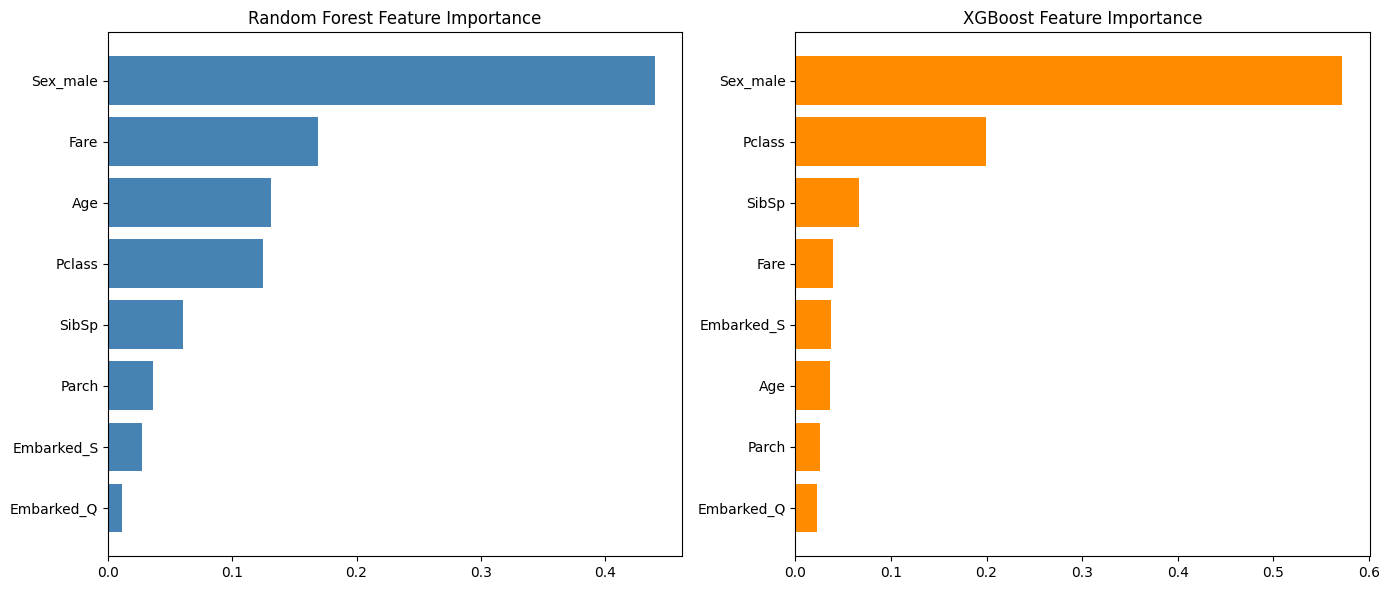

Random Forest top 3:
    Feature  Importance
5  Sex_male    0.440235
4      Fare    0.169212
1       Age    0.131349

XGBoost top 3:
    Feature  Importance
5  Sex_male    0.572044
0    Pclass    0.199429
2     SibSp    0.066678


In [8]:
import matplotlib.pyplot as plt

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='steelblue')
axes[0].set_title('Random Forest Feature Importance')
axes[0].invert_yaxis()

axes[1].barh(xgb_importance['Feature'], xgb_importance['Importance'], color='darkorange')
axes[1].set_title('XGBoost Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Random Forest top 3:")
print(rf_importance.head(3))
print("\nXGBoost top 3:")
print(xgb_importance.head(3))

## How Random Forest and XGBoost Differ

Random Forest builds many decision trees independently and in parallel, 
each trained on a random subset of the data and features, then averages 
their predictions (or takes a majority vote) to reduce overfitting — 
this is called "bagging." XGBoost instead builds trees sequentially, 
where each new tree is trained specifically to correct the errors made 
by the trees before it — this is called "boosting." Because of this, 
XGBoost often achieves higher accuracy on structured/tabular data like 
this dataset, but it's more sensitive to hyperparameter choices and can 
overfit more easily if not tuned carefully. Random Forest tends to be 
more robust out-of-the-box with less tuning required, making it a 
reliable baseline before reaching for a more complex boosted model.